**<h1> Introduction to RDKit<h1>**
<h5>

Table of Content:

1. **Introduction to RDKit**  
1.1   Visualize molecules  
1.2   Standardizing molecules       
1.3   Featurizing molecules      
2. **PubChempy**  
3. **Summary**  
</h5>

# **1 Introduction to RDKit**

**<h3> What is RDKit?**  
<h5>
RDKit is an open-source cheminformatics library for working with molecules in Python.  

**It allows you to**:
- Read and write molecular fomats (e.g. SMILES)
- Visualize molecules
- Calculate molecular properties (descriptors)
- Generate molecular fingerprints
- Search for substructures and functional groups (using SMARTS)
- Compare molecules
- And much more ...

> **In short: RDKit helps you turn chemical structures into something a computer can understand.**

In [1]:
# Install RDKit
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 36.5 MB/s eta 0:00:00


In [2]:
# Import some RDKIT modules
from rdkit import Chem                   # the core module
from rdkit.Chem import Draw              # drawing molecules
from rdkit.Chem import Descriptors       # molecular descriptors (MW, LogP, etc)
from rdkit.Chem import AllChem           # fingerprints and more
from rdkit import DataStructs            # similarity (Tanimoto, etc)
from rdkit.Chem import PandasTools       # rdkit + Pandas
from rdkit.Chem import rdMolDescriptors  # more advances descriptors
from rdkit.Chem import Lipinski          # Lipinski's Rule of Five descriptors

In [3]:
import pandas as pd # Import the pandas library for data manipulation
import numpy as np # Import the numpy library for numerical operations

**First some information about SMILES? What are SMILES?**  
SMILES (Simplified Molecular Input Line Entry System)  are a way to represent chemical structures as a simple text string.  

Instead of drawing a molecule, you write it as a line of text:
- Ethanol → `CCO`
- Benzene → `c1ccccc1`
- Caffeine → `Cn1cnc2c1c(=O)n(C)c(=O)n2C`  

SMILES encode:
- Atoms (C, O, N, etc.)
- Bonds (single, double `=`, triple `#`)
- Branches `()`
- Rings (numbers like `1`)

> **A SMILES string is a compact, computer-readable description of a molecule.**
> **SMILES are the starting point of almost every ML project involving molecules.**

## **1.1 Visualize molecules**

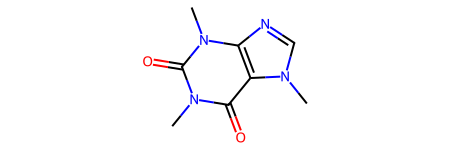

In [4]:
smiles = 'Cn1cnc2c1c(=O)n(C)c(=O)n2C'   # Define the SMILES string for caffeine
mol = Chem.MolFromSmiles(smiles)        # Convert the SMILES string to RDKit Mol object
mol                                     # Display the RDKit Mol object

# Tip: the drawing of the molecule can be copied!

**<h5> Draw multiple molecules**

Let's define a list of common drugs with their names and SMILES strings. This data will be used to demonstrate how to draw multiple molecules in RDKit.

In [5]:
name = ['Aspirin', 'Paracetamol', 'Ibuprofen', 'Amoxicillin', 'Omeprazole',
        'Lisinopril', 'Metformin', 'Levothyroxine', 'Atorvastatin', 'Diazepam'
        ]

smiles = ['CC(=O)Oc1ccccc1C(=O)O', # Aspirin
          'CC(=O)Nc1ccc(O)cc1',   # Paracetamol
          'CC(C)CC(C(=O)O)c1ccc(C)cc1', # Ibuprofen
          'CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(=O)N2C1C(=O)O', # Amoxicillin
          'Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1', # Omeprazole
          'NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O', # Lisinopril
          'CN(C)C(=N)NC(=N)N',   # Metformin
          'Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I', # Levothyroxine
          'CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C', # Atorvastatin
          'CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1', # Diazepam
          ]


In [7]:
# create dataframe from name list and smiles list
df_common_drugs = pd.DataFrame({'name': name, 'smiles': smiles})
df_common_drugs

,name,smiles
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O
1,Paracetamol,CC(=O)Nc1ccc(O)cc1
2,Ibuprofen,CC(C)CC(C(=O)O)c1ccc(C)cc1
3,Amoxicillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...
4,Omeprazole,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1
5,Lisinopril,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O
6,Metformin,CN(C)C(=N)NC(=N)N
7,Levothyroxine,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I
8,Atorvastatin,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C
9,Diazepam,CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1


**Converting SMILES to an RDKit Mol Object**

In RDKit, molecules are represented as Mol objects. A Mol object is a structured and chemically aware representation of a molecule that allows us to perform calculations, visualization, and machine learning.

A SMILES string is a simple text representation of a molecule (e.g. "CCO" for ethanol). However, SMILES is just text, to actually work with the molecule in Python, we must convert it into a Mol object.

Conversion

If the SMILES string is valid, the variable mol now contains the molecular structure.

**What can we do with an RDKit Mol object?**

Once a molecule is converted into a Mol object, it becomes a powerful, computation-ready representation that enables many types of analysis and operations.

1. Visualize molecules You can generate 2D images of molecules for quick inspection and understanding.

2. Access atoms and bonds You can loop through atoms and bonds to extract detailed information such as element types, bond orders, and connectivity.

3. Calculate molecular properties RDKit can compute properties like molecular weight, logP, number of hydrogen bond donors/acceptors, and more.

4. Generate features for machine learning Mol objects can be converted into numerical representations such as fingerprints or descriptors, which are essential for building ML models.

5. Perform substructure searches You can search for specific functional groups or patterns in molecules using SMARTS queries.

6. Modify molecules You can edit structures by adding/removing atoms or bonds, or performing chemical transformations.

7. Compare molecules Mol objects can be used to calculate similarity between molecules (e.g. Tanimoto similarity).

> **Key takeaway**  
> The Mol object is not just a structure; it is the central object that allows you to analyze, transform, and model molecules in RDKit.

In [8]:
# Add mol objects to the dataframe
df_common_drugs['mol'] = df_common_drugs['smiles'].apply(Chem.MolFromSmiles)
df_common_drugs

,name,smiles,mol
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9cb0>
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9620>
2,Ibuprofen,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9380>
3,Amoxicillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca960>
4,Omeprazole,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9c40>
5,Lisinopril,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9700>
6,Metformin,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca7a0>
7,Levothyroxine,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d20>
8,Atorvastatin,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d90>
9,Diazepam,CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9e00>


Alternative for 'list comprehension' using a 'loop'
<details>

```python
# Create an empty list to store molecule objects
mol_list = []

# Loop through all SMILES strings
for smiles in df_common_drugs['SMILES']:

    # Convert SMILES to an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)

    # Add molecule to the list
    mol_list.append(mol)

# Add the molecule list to the dataframe
df_common_drugs['mol'] = mol_list

# Show dataframe
df_common_drugs
```

In [9]:
# For drawing all molecules we first need to convert
# the mol objects and the names to a list
mols = df_common_drugs['mol'].tolist()
names = df_common_drugs['name'].tolist()

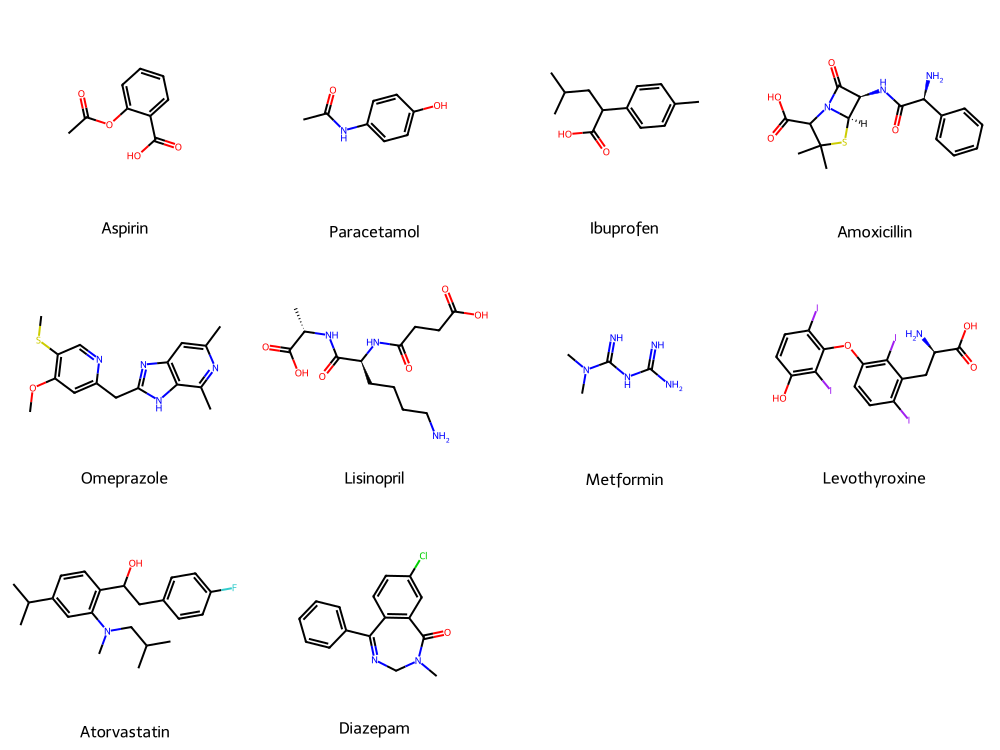

In [10]:
img = Draw.MolsToGridImage(
    mols,                       # mol objects
    molsPerRow=4,               # Adjust as needed
    subImgSize=(250, 250),      # Image size
    legends=names               # add labels
)
img

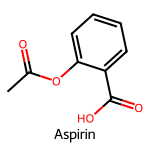

In [11]:
# Draw a selected molecule with its name as a legend
# Remember in Python we start to count from 0

molecule_number = 0 # select a molecule by its index in df_common_drugs dataframe
mol = df_common_drugs['mol'].iloc[molecule_number]
name = df_common_drugs['name'].iloc[molecule_number]

img = Draw.MolToImage(
    mol,                        # RDKit Mol object
    size=(150, 150),            # Image size
    legend=name                 # Add the molecule's name as a legend
)
img

## **1.2 Standardizing molecules**

**Cleaning Molecule Dataset**

In real-world datasets, molecular data represented as SMILES is often **inconsistent and noisy**. Before using this data for analysis or machine learning, it is essential to clean and standardize it to ensure reliability and consistency.

Common issues in raw SMILES datasets include missing values, invalid structures, formatting problems (such as extra spaces), duplicate entries, and different SMILES representations of the same molecule. Some entries may also contain multiple molecules (e.g. salts or mixtures), which may give issues for machine learning.

---

**Most important steps in the cleaning process**

**1. Remove missing and empty data**  
Entries that are empty or missing cannot be used and should be removed first.

**2. Fix formatting issues**
Clean simple text problems such as leading or trailing whitespace to ensure consistent input.

**3. Validate SMILES**  
Check whether each SMILES string represents a valid molecule. Invalid entries must be removed.

**4. Convert smiles to mol objects**  
Transform SMILES into a molecular representation (Mol object) to enable further processing.

**5. Standardize (canonical SMILES)**  
Different SMILES can describe the same molecule. Converting them to a **canonical form** ensures that each molecule has a unique and consistent representation.

**6. Remove duplicates**  
After standardization, identical molecules can be identified and duplicate entries can be removed (if required).

**7. Handle salts and mixtures**  
SMILES containing multiple fragments (e.g. salts: O=C[O-].[Na+]) should be removed or simplified so that each row represents a single molecule.

---

**Final result**

After these steps, the dataset:

- Contains only valid molecules  
- Has consistent and standardized representations  
- Contains no duplicates   
- Represents one molecule per row  

---

**Key takeaway**

> **Cleaning molecular data is a crucial step in cheminformatics. Often time consuming!!!  
It ensures that the dataset is **accurate, consistent, and ready for analysis or machine learning**, which ultimately leads to more reliable and meaningful results.**

In [12]:
# Lets create a dataframe containing raw data which must be cleaned !!
raw_data = {
    'SMILES': [
        'CC(=O)Oc1ccccc1C(=O)O',  # Aspirin /
        'O=C(C)Oc1ccccc1C(=O)O',   # Aspirin / in a different smiles notation
        'O=C(O)c1ccccc1OC(=O)C',   # Aspirin / in a different smiles notation
        None,
        '    CC(=O)Nc1ccc(O)cc1   ',   # Paracetamol / with extra white space
        'CC(C)CC(C(=O)O)c1ccc(C)cc1', # Ibuprofen
        'NOT A SMILES', # invalid smiles
        '', # No data
        None,
        '123456', # invalid data
        'CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(=O)N2C1C(=O)O', # Amoxicillin
        'Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1', # Omeprazole
        'NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O', # Lisinopril
        'CN(C)C(=N)NC(=N)N',   # Metformin
        'Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I', # Levothyroxine
        'CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C', # Atorvastatin
        None,
        'CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1.CCC' # Diazepam salt
        'CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1' # Diazepam
        'CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1' # Diazepam / duplicate
    ]
}

df_raw_data = pd.DataFrame(raw_data) # Convert list into a DataFrame
df_raw_data # Dataframe

,SMILES
0,CC(=O)Oc1ccccc1C(=O)O
1,O=C(C)Oc1ccccc1C(=O)O
2,O=C(O)c1ccccc1OC(=O)C
3,None
4,CC(=O)Nc1ccc(O)cc1
5,CC(C)CC(C(=O)O)c1ccc(C)cc1
6,NOT A SMILES
7,
8,None
9,123456


In [13]:
len(df_raw_data) # The number of data entries in the original raw data set !

18

In [14]:
df_raw_data = df_raw_data.dropna(subset=['SMILES'])
len(df_raw_data)

15

In [15]:
# Fix formatting issues - Strip whitespace
df_raw_data.loc[:, "SMILES"] = df_raw_data["SMILES"].str.strip()

In [16]:
# Remove empty strings
df_raw_data = df_raw_data[df_raw_data["SMILES"] != ""].copy()
len(df_raw_data)

14

In [17]:
# Convert all smiles to mol objects
df_raw_data["mol"] = [Chem.MolFromSmiles(s) for s in df_raw_data["SMILES"]]
df_raw_data

[12:08:09] SMILES Parse Error: syntax error while parsing: NOT
[12:08:09] SMILES Parse Error: check for mistakes around position 3:
[12:08:09] NOT
[12:08:09] ~~^
[12:08:09] SMILES Parse Error: Failed parsing SMILES 'NOT' for input: 'NOT'
[12:08:09] SMILES Parse Error: syntax error while parsing: 123456
[12:08:09] SMILES Parse Error: check for mistakes around position 1:
[12:08:09] 123456
[12:08:09] ^
[12:08:09] SMILES Parse Error: Failed parsing SMILES '123456' for input: '123456'


,SMILES,mol
0,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2fa70>
1,O=C(C)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2e880>
2,O=C(O)c1ccccc1OC(=O)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f840>
4,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2fe60>
5,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2e110>
6,NOT A SMILES,None
9,123456,None
10,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f290>
11,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f300>
12,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f370>


In [18]:
# Remove invalid smiles / molecules (where mol = None)
df_raw_data = df_raw_data[df_raw_data["mol"].notnull()].copy()
len(df_raw_data)

12

In [19]:
# Standardize to Canonical SMILES
# or this we convert the mol objects back to (canonical) smiles
canonical_smiles = []
for mol in df_raw_data["mol"]:
    canonical_smiles.append(Chem.MolToSmiles(mol, canonical=True))

df_raw_data["smiles_canonical"] = canonical_smiles
df_raw_data

,SMILES,mol,smiles_canonical
0,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2fa70>,CC(=O)Oc1ccccc1C(=O)O
1,O=C(C)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2e880>,CC(=O)Oc1ccccc1C(=O)O
2,O=C(O)c1ccccc1OC(=O)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f840>,CC(=O)Oc1ccccc1C(=O)O
4,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2fe60>,CC(=O)Nc1ccc(O)cc1
5,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2e110>,Cc1ccc(C(CC(C)C)C(=O)O)cc1
10,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f290>,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...
11,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f300>,COc1cc(Cc2nc3cc(C)nc(C)c3[nH]2)ncc1SC
12,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f370>,C[C@H](NC(=O)[C@H](CCCCN)NC(=O)CCC(=O)O)C(=O)O
13,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f3e0>,CN(C)C(=N)NC(=N)N
14,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f450>,N[C@H](Cc1c(I)ccc(Oc2c(I)ccc(O)c2I)c1I)C(=O)O


In [20]:
# Remove duplicates (same canonical smiles) - if required
df_raw_data = df_raw_data.drop_duplicates(subset="smiles_canonical")
len(df_raw_data)

10

In [21]:
# Remove smiles containing dots (.) e.g. salts and mixtures
df_raw_data = df_raw_data[~df_raw_data["SMILES"].str.contains(r"\.")].copy()
len(df_raw_data)

9

In [22]:
# Check the clean dataset !
df_raw_data

,SMILES,mol,smiles_canonical
0,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2fa70>,CC(=O)Oc1ccccc1C(=O)O
4,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2fe60>,CC(=O)Nc1ccc(O)cc1
5,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2e110>,Cc1ccc(C(CC(C)C)C(=O)O)cc1
10,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f290>,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...
11,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f300>,COc1cc(Cc2nc3cc(C)nc(C)c3[nH]2)ncc1SC
12,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f370>,C[C@H](NC(=O)[C@H](CCCCN)NC(=O)CCC(=O)O)C(=O)O
13,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f3e0>,CN(C)C(=N)NC(=N)N
14,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f450>,N[C@H](Cc1c(I)ccc(Oc2c(I)ccc(O)c2I)c1I)C(=O)O
15,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73b2f4c0>,CC(C)CN(C)c1cc(C(C)C)ccc1C(O)Cc1ccc(F)cc1


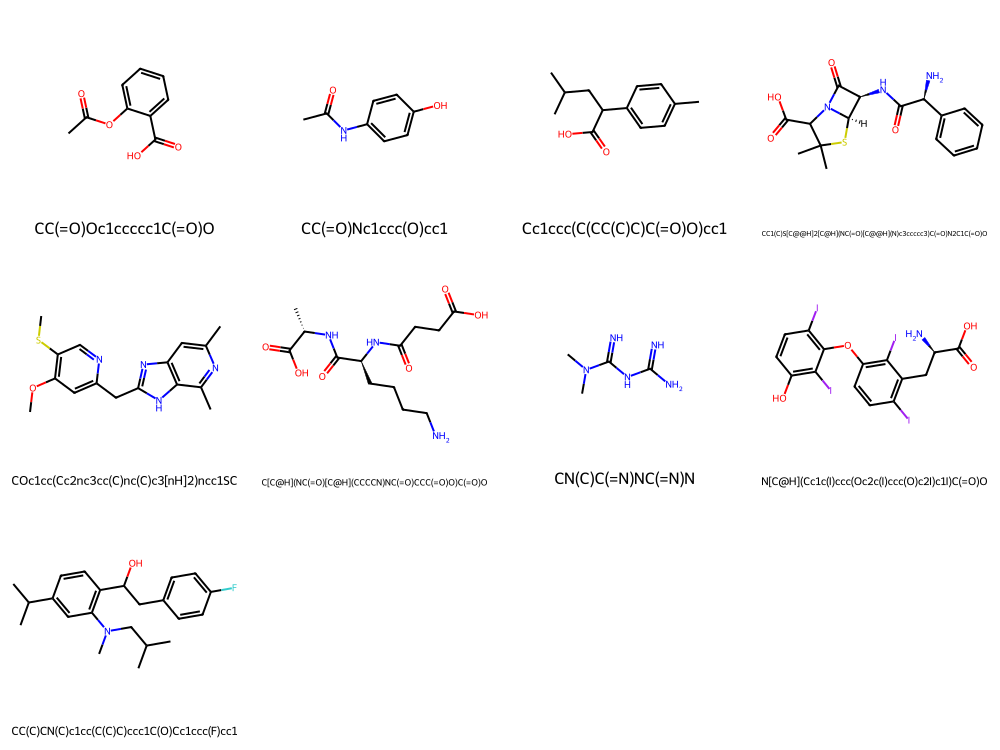

In [23]:
# Draw the cleaned dataset !
Draw.MolsToGridImage(
    df_raw_data["mol"].tolist(),
    molsPerRow=4,
    legends=df_raw_data["smiles_canonical"].tolist(),
    subImgSize=(250,250)
    )

## **1.3 Featurizing molecules**

**Featurization of Molecules for Machine Learning**

Machine learning models cannot work directly with molecules or SMILES strings.  
In general, they require **numerical input**. Therefore, molecules must be converted into numbers; this process is called **featurization**.

In cheminformatics, there are three main and widely used approaches to featurize molecules:

---

**1. Molecular Descriptors**

Descriptors are **calculated numerical properties** of a molecule.

Examples:
- Molecular weight  
- Number of atoms  
- LogP (lipophilicity)  
- Number of hydrogen bond donors/acceptors  

> Descriptors summarize the molecule using a set of meaningful chemical properties.

- Easy to understand  
- Interpretable  
- May miss detailed structural information  

---

**2. Molecular Fingerprints**

Fingerprints are **binary vectors (lists of 0s and 1s)** that encode the presence or absence of structural features.

Example:
- A vector like: `[0,1,0,1,1,0,...]`

The most common type is:
- **Morgan fingerprints (circular fingerprints)**

> Each bit represents a specific structural pattern in the molecule.

+ Very popular in machine learning  
+ Captures structural information  
+ Works well for similarity and prediction tasks  
+ Hard to interpret (what each bit means is not always clear)

---

**3. Molecular Graphs**

A molecule can also be represented as a **graph**:

- Atoms → nodes  
- Bonds → edges  

This representation is used in:
- **Graph Neural Networks (GNNs)**

> Instead of predefined features, the model learns directly from the structure.

- Most flexible and powerful  
- Captures full molecular structure  
- More complex and advanced  

---

**Summary**

| Method        | Idea                          | Complexity
|--------------|-------------------------------|------------|
| Descriptors  | Chemical properties           | Low        |
| Fingerprints | Structural patterns (bits)    | Medium     |
| Mol Graphs   | Full molecular structure      | High       |

---

**Key takeaway**

>Featurization = **convert molecules into numbers**  
>The three main approaches are:
>-    **1 Descriptors**
>-    **2 Fingerprints**
>-    **3 Molecular graphs**


### **1.3.1 Molecular descriptors**

Molecular descriptors are **numerical values** that describe properties of a molecule.  
They convert chemical structures (SMILES or Mol objects) into numbers that can be used as input for machine learning models.

Instead of working directly with chemical structures, we summarize each molecule using a set of meaningful properties such as size, polarity, and bonding behavior.

---

By using RDKIT **more than 200 descriptors** can be calculated and used as input for ML.  
For a first introduction, it is best to focus on a small set of intuitive and widely used descriptors:

- **Molecular Weight (MolWt)**  
  The size of the molecule in terms of mass.

- **LogP (MolLogP)**  
  A measure of how hydrophobic (fat-loving) or hydrophilic (water-loving) a molecule is.

- **TPSA (Topological Polar Surface Area)**  
  Indicates the polarity of a molecule and is related to solubility and permeability.

- **Number of Atoms (NumAtoms)**  
  A simple measure of molecular size.

- **Hydrogen Bond Donors (NumHDonors)**  
  Number of atoms that can donate a hydrogen bond.

- **Hydrogen Bond Acceptors (NumHAcceptors)**  
  Number of atoms that can accept a hydrogen bond.

- **Number of Rotatable Bonds (NumRotatableBonds)**  
  Indicates molecular flexibility.

---

Key idea

>Descriptors transform a molecule into a **vector of numbers**:  
>Molecule → Descriptors → Machine Learning input    
>Starting with a small set of clear and interpretable descriptors is the best way to understand how molecular features relate to chemical behavior and model predictions.

In [24]:
# Dataset
df_common_drugs

,name,smiles,mol
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9cb0>
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9620>
2,Ibuprofen,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9380>
3,Amoxicillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca960>
4,Omeprazole,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9c40>
5,Lisinopril,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9700>
6,Metformin,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca7a0>
7,Levothyroxine,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d20>
8,Atorvastatin,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d90>
9,Diazepam,CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9e00>


In [25]:
# Lets calculate the descriptor: molecular weight (mw)
# and add to our dataframe

mw_list = [] # define the list (now empty) for all molecular weights
for mol in df_common_drugs["mol"]:
    mw_list.append(Descriptors.MolWt(mol))

# Add list of all calculated molecular weight to our dataframe
df_common_drugs["mw"] = mw_list
df_common_drugs

,name,smiles,mol,mw
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9cb0>,180.159
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9620>,151.165
2,Ibuprofen,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9380>,206.285
3,Amoxicillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca960>,349.412
4,Omeprazole,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9c40>,314.414
5,Lisinopril,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9700>,317.342
6,Metformin,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca7a0>,129.167
7,Levothyroxine,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d20>,776.872
8,Atorvastatin,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d90>,343.486
9,Diazepam,CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9e00>,284.746


In [26]:
# Lets calculate the descriptor: logP weight
# and add to our dataframe

logp_list = [] # define the list (now empty) for all logp values
for mol in df_common_drugs["mol"]:
    logp_list.append(Descriptors.MolLogP(mol))

# Add list of all calculated molecular weight to our dataframe
df_common_drugs["logP"] = logp_list
df_common_drugs

,name,smiles,mol,mw,logP
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9cb0>,180.159,1.31010
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9620>,151.165,1.35060
2,Ibuprofen,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9380>,206.285,3.20932
3,Amoxicillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca960>,349.412,0.31810
4,Omeprazole,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9c40>,314.414,3.29104
5,Lisinopril,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9700>,317.342,-0.94570
6,Metformin,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca7a0>,129.167,-1.03416
7,Levothyroxine,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d20>,776.872,4.55730
8,Atorvastatin,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d90>,343.486,5.31740
9,Diazepam,CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9e00>,284.746,3.22050


In [27]:
# We can also add multiple descriptors at the same time to our dataframe
# Lets add the number of Hydrogen donors and acceptors
donors_list = []
acceptors_list = []
for mol in df_common_drugs["mol"]:
    donors_list.append(Lipinski.NumHDonors(mol))
    acceptors_list.append(Lipinski.NumHAcceptors(mol))
df_common_drugs["H_donors"] = donors_list
df_common_drugs["H_acceptors"] = acceptors_list
df_common_drugs

,name,smiles,mol,mw,logP,H_donors,H_acceptors
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9cb0>,180.159,1.31010,1,3
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9620>,151.165,1.35060,2,2
2,Ibuprofen,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9380>,206.285,3.20932,1,1
3,Amoxicillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca960>,349.412,0.31810,3,5
4,Omeprazole,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9c40>,314.414,3.29104,1,5
5,Lisinopril,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9700>,317.342,-0.94570,5,5
6,Metformin,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca7a0>,129.167,-1.03416,4,2
7,Levothyroxine,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d20>,776.872,4.55730,3,4
8,Atorvastatin,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d90>,343.486,5.31740,1,2
9,Diazepam,CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9e00>,284.746,3.22050,0,2


### **1.3.2 Molecular Fingerprints**

**Molecular Fingerprints**

What are Molecular Fingerprints?

>Molecular fingerprints are a way to represent a molecule as a **vector of numbers (usually 0s and 1s)**.

Instead of working with the chemical structure directly, we convert a molecule into a **numerical format** that machine learning models can understand.

Example (simplified):

Molecule → Fingerprint  
`CCO` → `[0, 1, 0, 1, 1, 0, ...]`

Each position (bit) in the fingerprint represents the **presence or absence of a certain structural pattern** in the molecule.

---

Why are Fingerprints Important?

Machine learning models cannot (easily) work with:
- SMILES strings  
- Chemical drawings  

They require **numerical input (features)**.

Molecular fingerprints:
- Encode **chemical structure** into numbers  
- Allow comparison between molecules  
- Are widely used in cheminformatics and ML  

>They are the **most important feature type** for many ML models in chemistry.

---

Types of Fingerprints (focus of this course)

In this course, we mainly use:

- **Morgan fingerprints (circular fingerprints)**
  - Based on atom neighborhoods
  - Very popular and powerful
  - Also known as ECFP (Extended Connectivity Fingerprints)

---

How it fits in the ML workflow

SMILES → RDKit mol object → **Fingerprint → ML model**

---

Key Idea
> Fingerprints translate chemistry into data.


In [28]:
from rdkit.Chem import rdFingerprintGenerator

# SMILES for caffeine
smiles = "Cn1cnc2c1c(=O)n(C)c(=O)n2C"

# Convert SMILES to mol object
mol = Chem.MolFromSmiles(smiles)

# Create Morgan fingerprint (new method)
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fp = fpgen.GetFingerprint(mol)

# Convert fingerprint to list
fp_list = list(fp)

# Print results
print("First 20 bits:", fp_list[:20])
print("Number of bits set to 1:", sum(fp_list))

First 20 bits: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Number of bits set to 1: 24


**Fingerprint Settings: Radius and fpSize**

When creating a Morgan fingerprint, two important parameters are:

**1. Radius**
- Defines how far the algorithm looks around each atom  
- Radius = 1 → only direct neighbors  
- Radius = 2 → neighbors of neighbors (most commonly used)  
- Radius = 3 → larger chemical environment  

>Larger radius = more structural information, but also more complexity

---

**2. fpSize**
- Defines the size (lenght) of the fingerprint (number of bits)  
- Common values: 512, 1024, 2048  


>Larger fingerprint:
- More space to store information  
- Less chance of overlap (collisions)  
- But more computational cost  

---

**Practical Choice**
- **Radius = 2** → good balance (standard choice)  
- **Length = 1024 or 2048** → commonly used  

---

> Start simple: radius = 2 and fpSize = 1024 works well for most ML projects.

Number of active bits: 24


[12:09:04] DEPRECATION WARNING: please use MorganGenerator


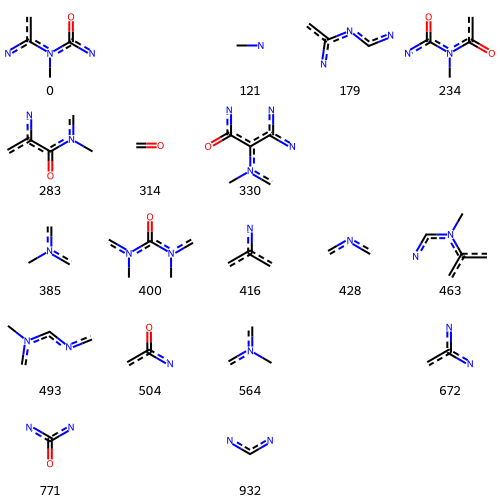

In [29]:
# FORGET THIS CODE
# THIS CODE IS ONLY TO VISUALIZE THE ACTIVE BITS (WHICH EQUALS 1)
from rdkit.Chem import rdFingerprintGenerator, Draw, AllChem # Added AllChem for GetMorganFingerprintAsBitVect

# Example molecule (caffeine)
smiles = "Cn1cnc2c1c(=O)n(C)c(=O)n2C"
mol = Chem.MolFromSmiles(smiles)

# Create Morgan fingerprint + bit info using AllChem.GetMorganFingerprintAsBitVect
bitInfo = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=bitInfo)

# Get active bits (bits = 1)
on_bits = list(fp.GetOnBits())
print("Number of active bits:", len(on_bits))

# Take a few bits to visualize
bits_to_show = on_bits[:1024]

# Create images of substructures
submols = []
legends = [] # List to hold the bit numbers as legends
for bit in bits_to_show:
    atom_id, radius = bitInfo[bit][0]  # take first match
    env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)
    submol = Chem.PathToSubmol(mol, env)
    submols.append(submol)
    legends.append(str(bit)) # Add the bit number to the legends list

# Draw substructures with bit numbers as legends
Draw.MolsToGridImage(
    submols,
    molsPerRow=5,
    subImgSize=(100,100),
    legends=legends # Pass the legends list here
)

In [30]:
# Calculate fingerprints of all molecules in our DataFrame
# and add them to the DataFrame
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
morgan_fingerprints = []
for mol_obj in df_common_drugs["mol"]:
    fp = fpgen.GetFingerprint(mol_obj)
    morgan_fingerprints.append(list(fp))

df_common_drugs["morgan_fp"] = morgan_fingerprints

In [31]:
df_common_drugs

,name,smiles,mol,mw,logP,H_donors,H_acceptors,morgan_fp
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9cb0>,180.159,1.31010,1,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
1,Paracetamol,CC(=O)Nc1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9620>,151.165,1.35060,2,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Ibuprofen,CC(C)CC(C(=O)O)c1ccc(C)cc1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9380>,206.285,3.20932,1,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Amoxicillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@@H](N)c3ccccc3)C(...,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca960>,349.412,0.31810,3,5,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Omeprazole,Cc1nc(C)c2[nH]c(Cc3ncc(SC)c(OC)c3)nc2c1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9c40>,314.414,3.29104,1,5,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,Lisinopril,NCCCC[C@H](NC(=O)CCC(=O)O)C(=O)N[C@@H](C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9700>,317.342,-0.94570,5,5,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,Metformin,CN(C)C(=N)NC(=N)N,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cca7a0>,129.167,-1.03416,4,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,Levothyroxine,Oc1ccc(I)c(Oc2ccc(I)c(C[C@@H](N)C(=O)O)c2I)c1I,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d20>,776.872,4.55730,3,4,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,Atorvastatin,CC(C)c1ccc(C(O)Cc2ccc(F)cc2)c(c1)N(C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9d90>,343.486,5.31740,1,2,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,Diazepam,CN1C(=O)c2cc(Cl)ccc2C(c2ccccc2)=NC1,<rdkit.Chem.rdchem.Mol object at 0x7d6b73cc9e00>,284.746,3.22050,0,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [33]:
# Compare two molecules
# Calculate the Tanimoto similariry

mol1_idx = 0
mol2_idx = 1

# Get the RDKit Mol objects for the selected molecules
mol1 = df_common_drugs['mol'].iloc[mol1_idx]
mol2 = df_common_drugs['mol'].iloc[mol2_idx]

# Generate Morgan fingerprints (ExplicitBitVect objects) directly from the mol objects
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fp1_bit_vect = fpgen.GetFingerprint(mol1)
fp2_bit_vect = fpgen.GetFingerprint(mol2)

# Calculate Tanimoto similarity
tanimoto_similarity = DataStructs.TanimotoSimilarity(fp1_bit_vect, fp2_bit_vect)
tanimoto_similarity

0.22857142857142856

# **2 PubChem**


In [34]:
# Install PubChemPy
!pip install PubChemPy

In [35]:
import pubchempy as pcp

In [44]:
# Search for a compound by name (e.g., Aspirin)
compound = pcp.get_compounds('Aspirin', 'name')
compound

[Compound(2244)]

In [41]:
compound[0].smiles

'CC(=O)OC1=CC=CC=C1C(=O)O'

In [45]:
compound[0].iupac_name

'2-acetyloxybenzoic acid'

In [46]:
compound[0].molecular_formula

'C9H8O4'

In [47]:
compound[0].xlogp

1.2

In [48]:
compound[0].synonyms

['aspirin',
 'ACETYLSALICYLIC ACID',
 '50-78-2',
 '2-Acetoxybenzoic acid',
 '2-(Acetyloxy)benzoic acid',
 'Acylpyrin',
 'O-Acetylsalicylic acid',
 'o-Acetoxybenzoic acid',
 'Acenterine',
 'Acetophen',
 'Ecotrin',
 'Salicylic acid acetate',
 'Aceticyl',
 'Acetosalin',
 'Polopiryna',
 'Aspirdrops',
 'Pharmacin',
 'Premaspin',
 'Salcetogen',
 'Acetonyl',
 'Benaspir',
 'Empirin',
 'Endydol',
 'Measurin',
 'Rhodine',
 'Saletin',
 'Temperal',
 'Adiro',
 'Ecolen',
 'Acetosalic acid',
 'Rheumintabletten',
 'Solprin acid',
 'o-Carboxyphenyl acetate',
 'Acidum acetylsalicylicum',
 '2-acetyloxybenzoic acid',
 'Enterosarine',
 'Acetisal',
 'Acetylsal',
 'Aspirine',
 'Bialpirina',
 'Bialpirinia',
 'Entericin',
 'Enterophen',
 'Globentyl',
 'Salacetin',
 'Solpyron',
 'Acesal',
 'Acisal',
 'Asagran',
 'Asteric',
 'Caprin',
 'Cemirit',
 'Duramax',
 'Extren',
 'Globoid',
 'Helicon',
 'Idragin',
 'Levius',
 'Rhonal',
 'Aspro',
 'Novid',
 'Yasta',
 'Benzoic acid, 2-(acetyloxy)-',
 'Acimetten',
 'Delgesic

In [49]:
dir(compound[0])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_atoms',
 '_bonds',
 '_record',
 '_setup_atoms',
 '_setup_bonds',
 '_synonyms',
 'aids',
 'atom_stereo_count',
 'atoms',
 'bond_stereo_count',
 'bonds',
 'cactvs_fingerprint',
 'canonical_smiles',
 'charge',
 'cid',
 'complexity',
 'conformer_id_3d',
 'conformer_rmsd_3d',
 'connectivity_smiles',
 'coordinate_type',
 'covalent_unit_count',
 'defined_atom_stereo_count',
 'defined_bond_stereo_count',
 'effective_rotor_count_3d',
 'elements',
 'exact_mass',
 'feature_selfoverlap_3d',
 'fingerprint',
 'from_cid',
 'h_bond_acceptor_count',
 'h_bond_donor_count',
 'heavy_atom_count',
 'inchi',
 'inchikey',
 'is

## 3 Summary



This workbook provides an introduction to cheminformatics using the RDKit library and some basic concepts of PubChem. Here are the most important things to remember:

- **RDKit is a powerful open-source cheminformatics library**: It allows you to work with molecules in Python, performing tasks like visualization, standardization, featurization, and more.

- **SMILES are fundamental**: Simplified Molecular Input Line Entry System (SMILES) strings are text-based representations of chemical structures and are the starting point for most machine learning projects involving molecules.

- **Mol Objects are RDKit's core**: To interact with molecules in RDKit, you must convert SMILES strings into Mol objects. These objects are chemically intelligent representations that enable various operations.

- **Data Cleaning is crucial**: Real-world molecular datasets are often messy. Essential cleaning steps include removing missing data, fixing formatting issues, validating SMILES, converting to Mol objects, standardizing to canonical SMILES, removing duplicates, and handling salts/mixtures. The dot . in SMILES indicates separate fragments, like in salts.

- **Molecules need Featurization for ML**: Machine learning models require numerical input. Molecules are converted into numbers through featurization, using:

    - **Molecular Descriptors**: Calculated numerical properties (e.g., molecular weight, LogP, number of hydrogen bond donors/acceptors). These are interpretable.
    - **Molecular Fingerprints**: Binary vectors representing the presence or absence of structural patterns (e.g., Morgan fingerprints). These are widely used for similarity and prediction tasks.
- **PubChemPy for external data**: The pubchempy library allows programmatic access to the PubChem database to retrieve molecular information (SMILES, IUPAC name, molecular formula, LogP, synonyms) using compound names or other identifiers.
